# Recoding sequence of interest

In [1]:
import re
import pandas as pd
import plotnine as pln

In [207]:
data = open("../examples/recoded/miRFP670nano3_recoded_to_Mahoney_pv_descr.txt").read()
construct_blocks = re.split(r"Construct:", data)[1:]

# Codon frequency

In [212]:
rows = []

for block in construct_blocks:
    name = block.split("\n")[0].strip()

    rel = re.search(r"--Relative frequencies--(.*?)-----------------------------------------------",
                    block, re.S)

    if rel:
        codons = re.findall(r"([ACGT]{3}):\s*([0-9.]+)", rel.group(1))

        for codon, freq in codons:
            rows.append({
                "Construct": name,
                "Codon": codon,
                "Frequency": float(freq)
            })

df = pd.DataFrame(rows)

In [209]:
ref_name = 'Mahoney_pv'

ref = df[df["Construct"]==ref_name][["Codon","Frequency"]]

ref = ref.rename(columns={"Frequency": ref_name})

freq = df.merge(ref, on="Codon")

In [210]:
order = (
    freq.groupby("Construct", observed=False)
      # compute the distance to the reference construct (square root of sum of squared differences)
      .apply(lambda x: ((x["Frequency"] - x[ref_name])**2).sum()**0.5, include_groups=False)
      .sort_values(ascending=True)
      .index
)

freq["Construct"] = pd.Categorical(freq["Construct"], categories=order, ordered=True)
freq

,Construct,Codon,Frequency,Mahoney_pv
0,Mahoney_pv,GCA,0.366,0.366
1,Mahoney_pv,GCC,0.217,0.217
2,Mahoney_pv,GCG,0.106,0.106
3,Mahoney_pv,GCT,0.311,0.311
4,Mahoney_pv,AGA,0.500,0.500
...,...,...,...,...
1093,C16,GTT,0.000,0.159
1094,C16,TGG,1.000,1.000
1095,C16,ATG,1.000,1.000
1096,C16,AAA,0.500,0.508


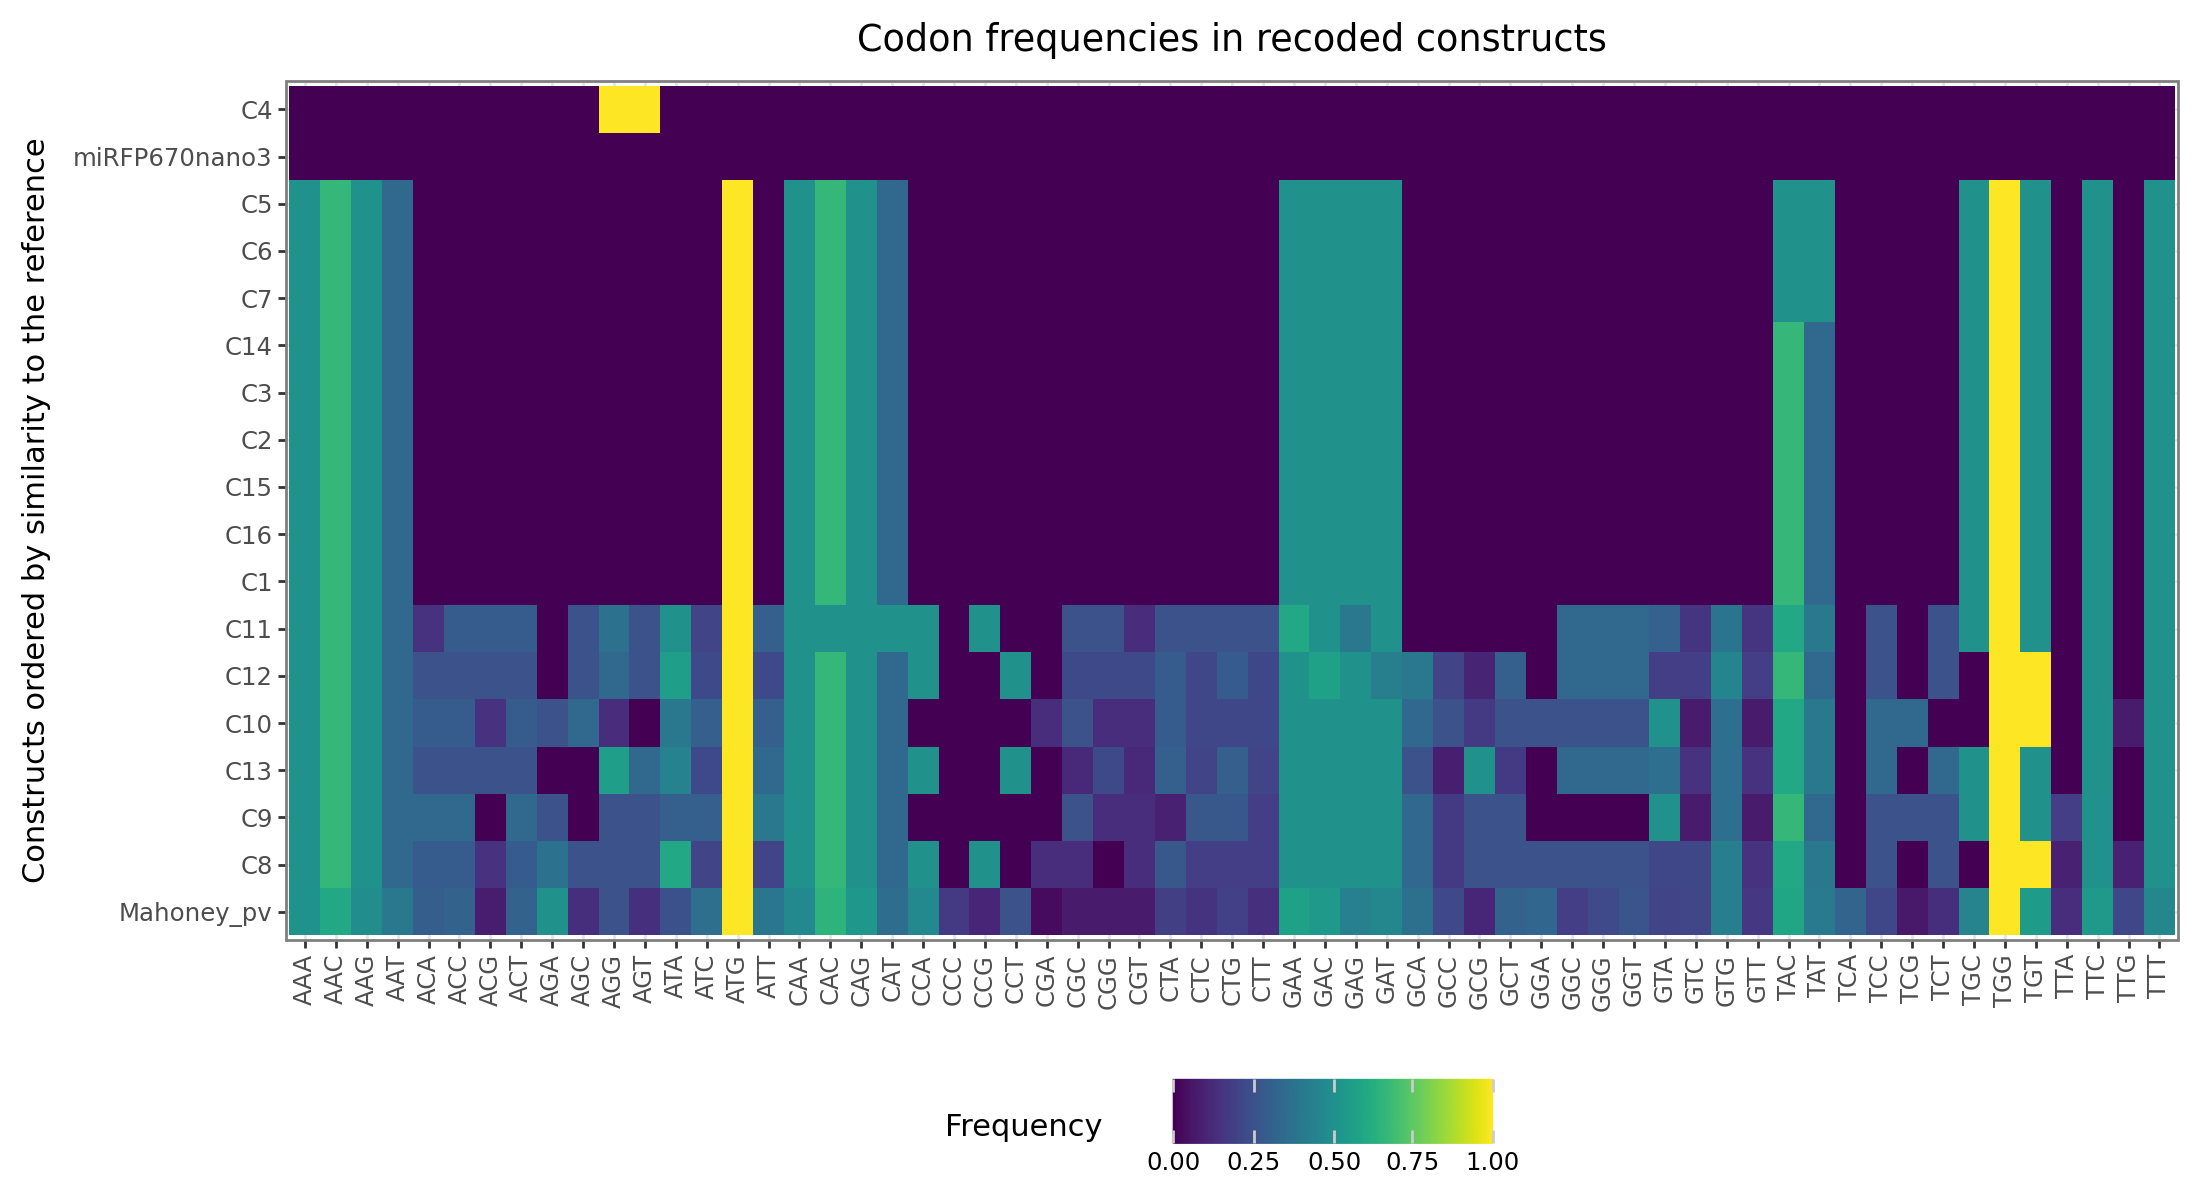

In [211]:
(
    pln.ggplot(freq, pln.aes(x="Codon", y="Construct", fill="Frequency")) +
    pln.geom_tile() +
    pln.theme_bw() +
    pln.theme(
        legend_position="bottom",
        axis_text_x=pln.element_text(angle=90),
        figure_size=(11,6),

    ) +
    pln.labs(title="Codon frequencies in recoded constructs", y="Constructs ordered by similarity to the reference", x="")
)

# Mutations to stop

In [ ]:

stats = {}
for block in construct_blocks:
    entries = block.split("\n")
    name = entries[0].strip()
    description = entries[1].replace("Description: ", "")

    rel = re.search(r"Mutations to stop: (\d+), CpG count: (\d+), UpA count: (\d+)", block, re.S)

    stats[name] = {
        "Description": description,
        "Mutations to stop": int(rel.groups()[0]),
        "CpG count": int(rel.groups()[1]),
        "UpA count": int(rel.groups()[2])
    }
    #print(name, "Mutations to stop: ", rel.groups()[0], ", CpG count: ", rel.groups()[1], ", UpA count: ", rel.groups()[2])


stats_df = pd.DataFrame.from_dict(stats, orient='index').reset_index()
stats_df.rename(columns={"index": "Construct"}, inplace=True)
stats_df  

,Construct,Description,Mutations to stop,CpG count,UpA count
0,Mahoney_pv,"Mahoney_pv poliovirus Mahoney strain, entire p...",898,174,363
1,miRFP670nano3,miRFP670nano3,59,0,0
2,C1,codon frequencies matched to Mahoney_pv strain,59,0,3
3,C2,codon frequencies matched to Mahoney_pv strain,59,0,3
4,C3,codon frequencies matched to Mahoney_pv strain,59,0,3
5,C4,"minimized mutations to stop, CpG, UpA",52,0,0
6,C5,codon frequencies matched to Mahoney_pv strain...,59,0,2
7,C6,codon frequencies matched to Mahoney_pv strain...,59,0,3
8,C7,codon frequencies matched to Mahoney_pv strain...,59,0,2
9,C8,codon frequencies and frequencies of mutations...,60,12,24


In [ ]:
{
    "C1-3":   "codon frequencies matched to Mahoney_pv strain",
    "C4":     "minimized mutations to stop, CpG, UpA",
    "C5-7":   "codon frequencies matched to Mahoney_pv strain and minimized mutations to stop, CpG, UpA",
    "C8-10":  "codon frequencies and frequencies of mutations to stop, CpG, UpA all matched to Mahoney_pv",
    "C11-13": "codon frequencies and frequencies of CpG, UpA matched to Mahoney_pv, minimized mutations to stop",
    "C14-16": "codon frequencies matched to Mahoney_pv, minimized CpG only ",
}

{'C1-3': 'codon frequencies matched to Mahoney_pv strain',
 'C4': 'minimized mutations to stop, CpG, UpA',
 'C5-7': 'codon frequencies matched to Mahoney_pv strain and minimized mutations to stop, CpG, UpA',
 'C8-10': 'codon frequencies and frequencies of mutations to stop, CpG, UpA all matched to Mahoney_pv',
 'C11-13': 'codon frequencies and frequencies of CpG, UpA matched to Mahoney_pv, minimized mutations to stop',
 'C14-16': 'codon frequencies matched to Mahoney_pv, minimized CpG only '}

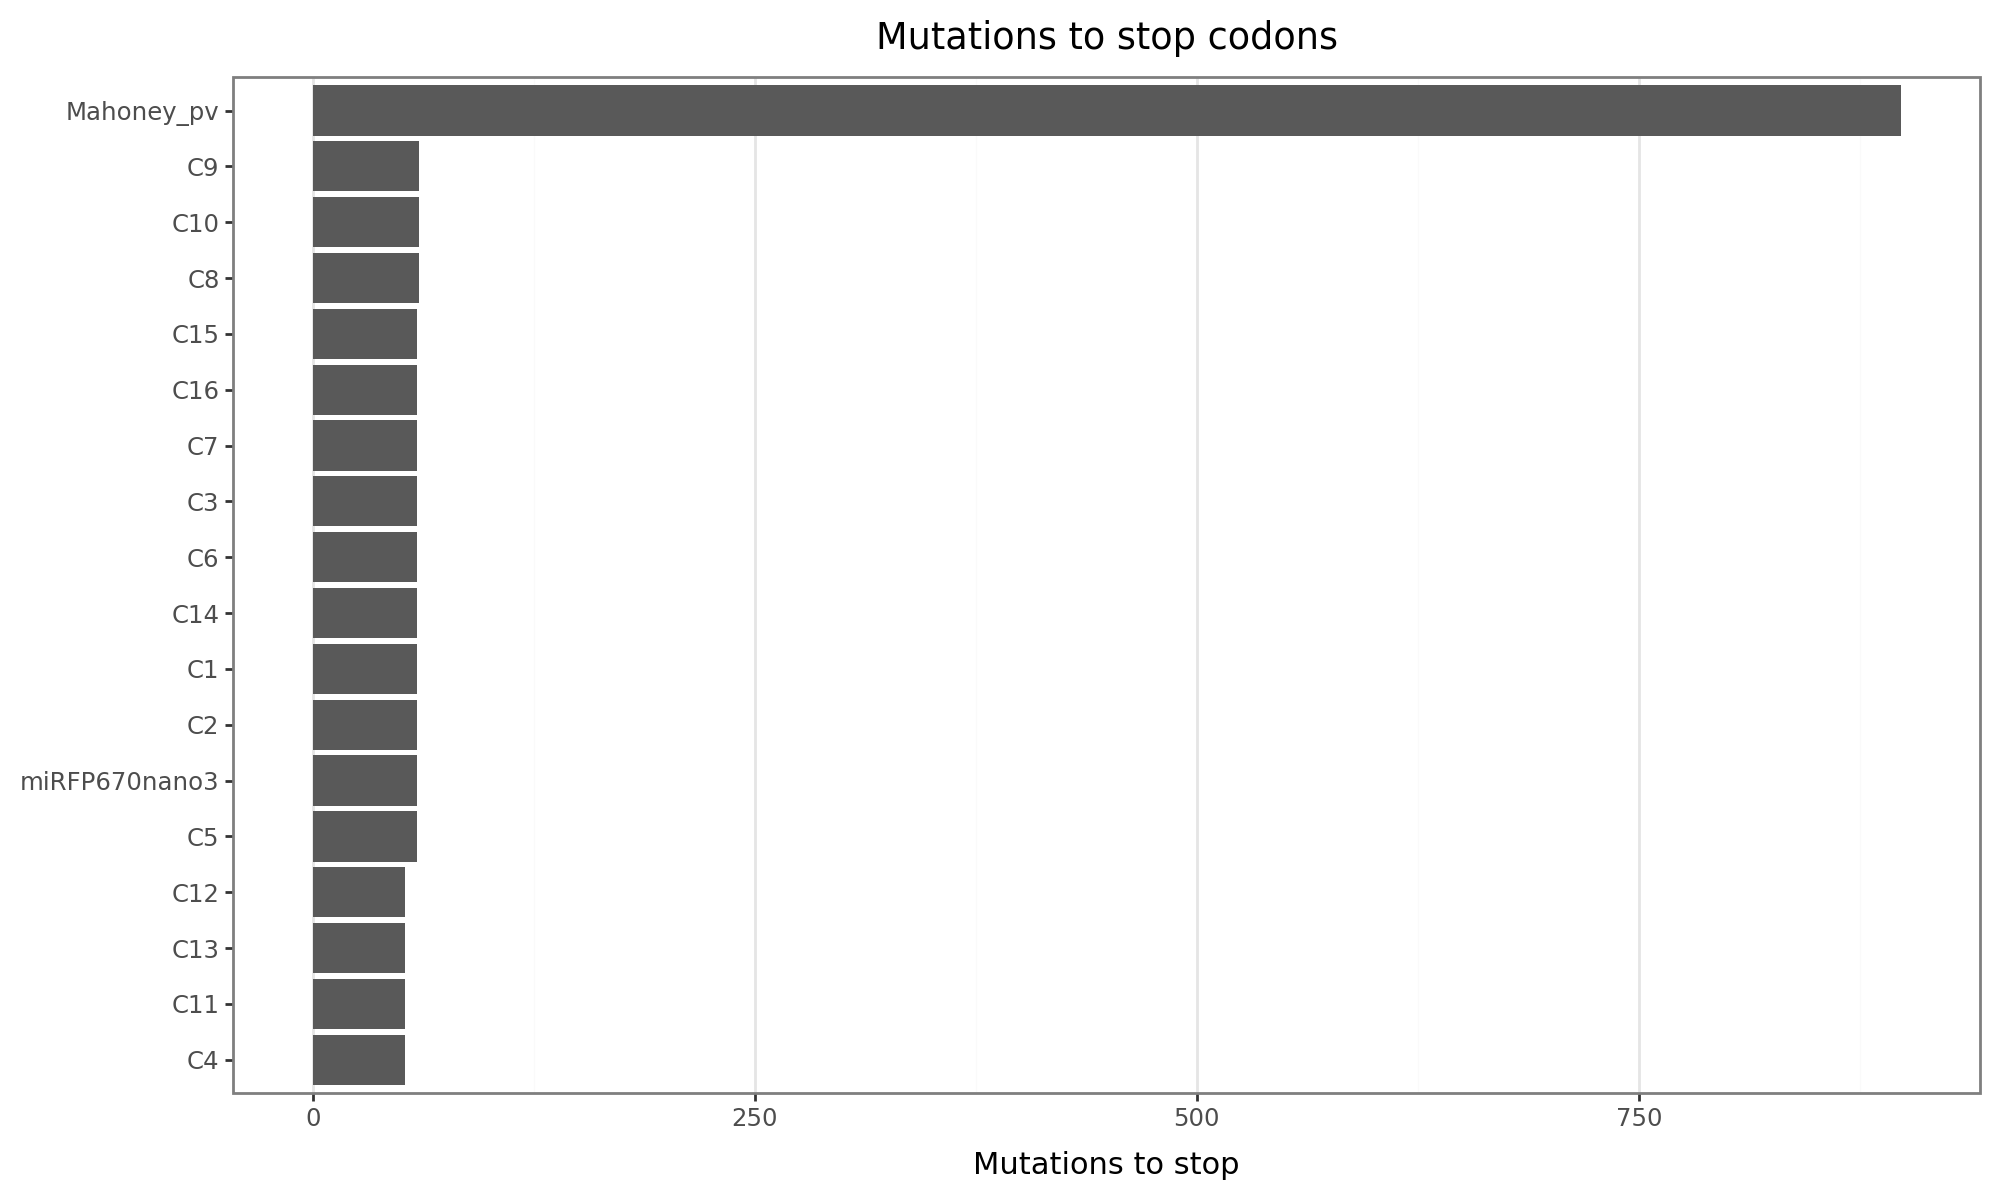

In [204]:
order = stats_df.sort_values("Mutations to stop")["Construct"]
stats_df["Construct"] = pd.Categorical(stats_df["Construct"], categories=order, ordered=True)


(
    pln.ggplot(stats_df, pln.aes(x="Construct", y="Mutations to stop")) +
    pln.geom_col() +
    pln.theme_bw() +
    pln.theme(
        panel_grid_major_y=pln.element_blank(),
        figure_size=(10,6),
    ) +
    pln.labs(title="Mutations to stop codons", x="") +
    pln.coord_flip() 
)

# CpG count

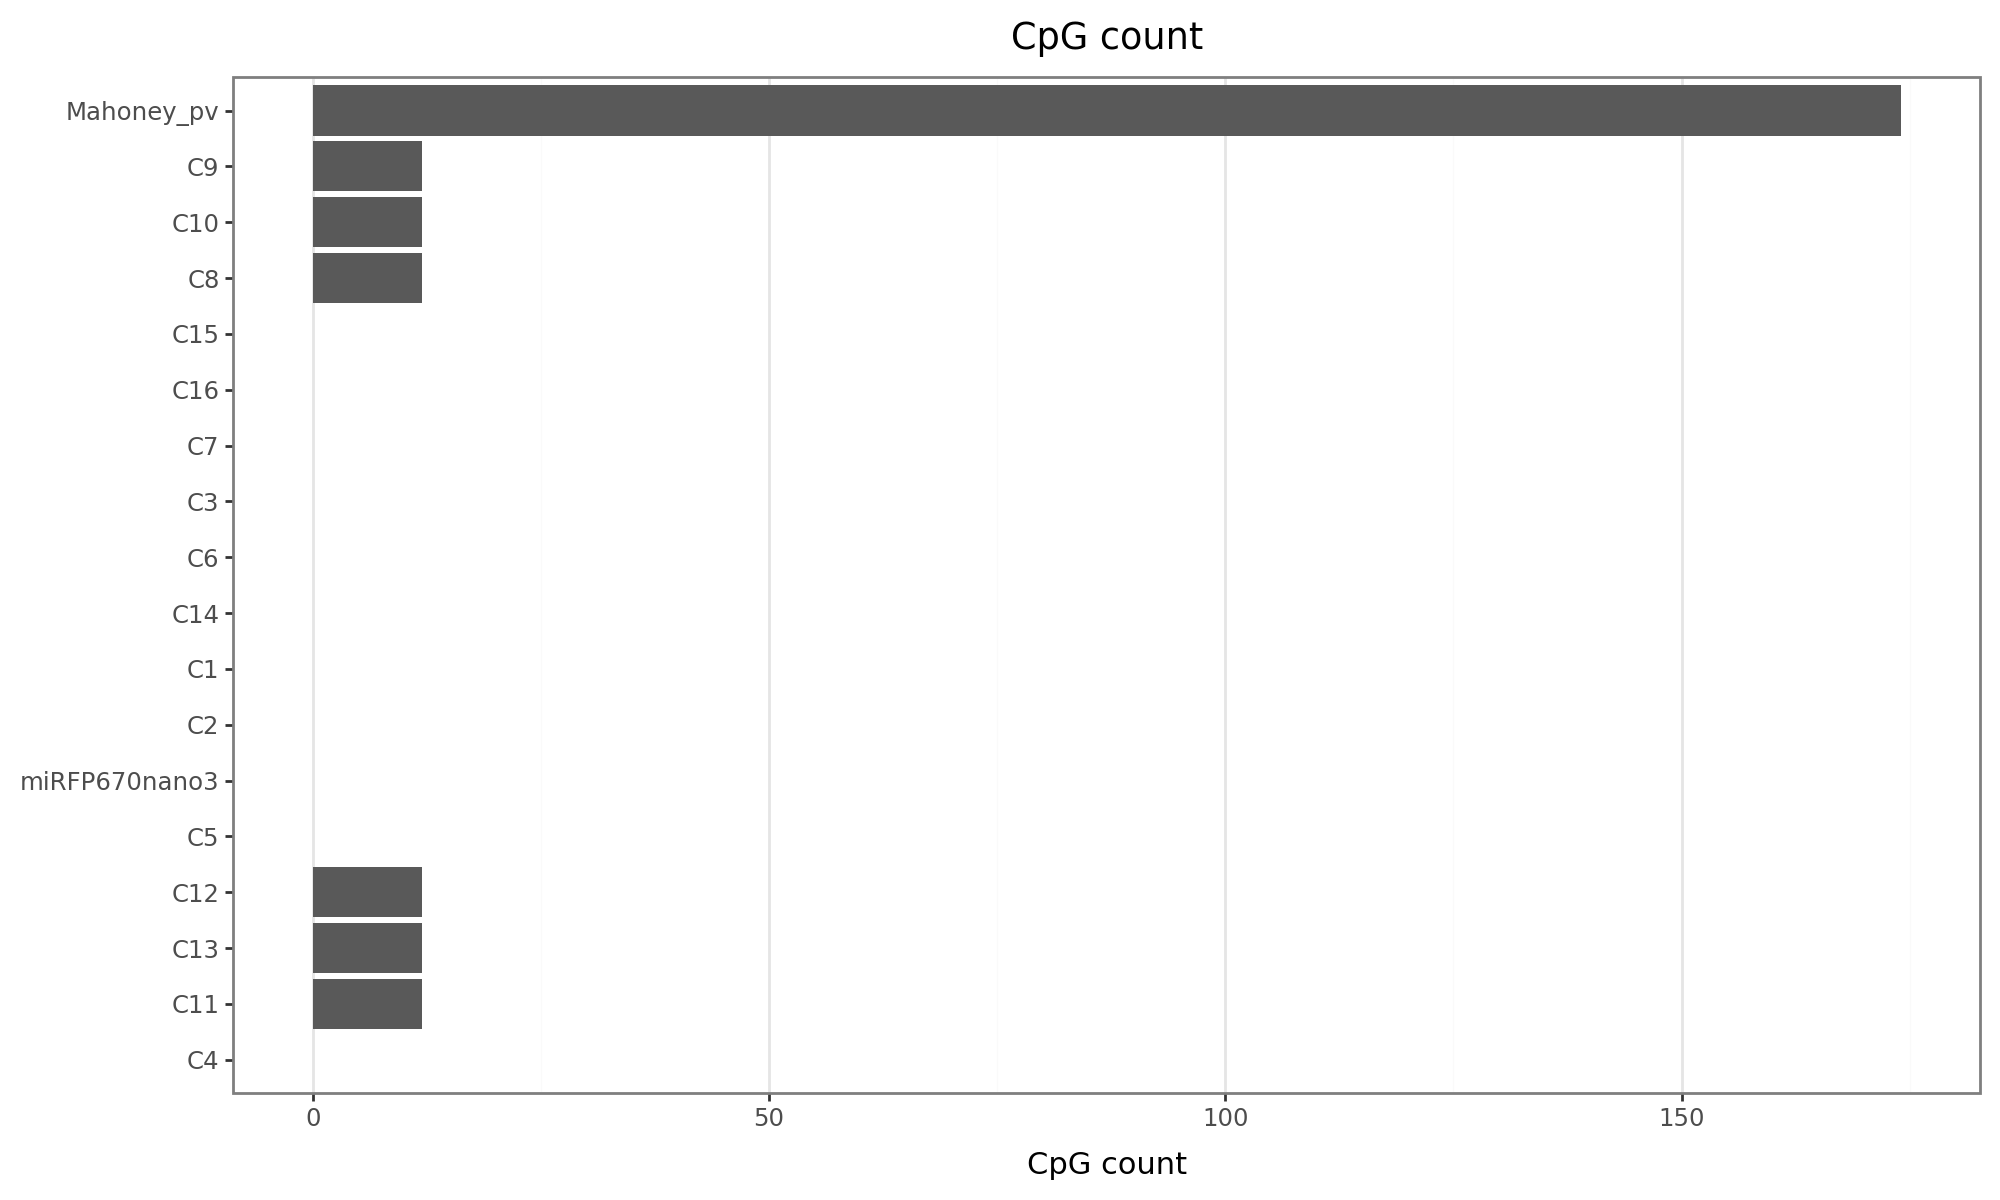

In [205]:
order = stats_df.sort_values("CpG count")["Construct"]
stats_df["Construct"] = pd.Categorical(stats_df["Construct"], categories=order, ordered=True)


(
    pln.ggplot(stats_df, pln.aes(x="Construct", y="CpG count")) +
    pln.geom_col() +
    pln.theme_bw() +
    pln.theme(
        panel_grid_major_y=pln.element_blank(),
        figure_size=(10,6),
    ) +
    pln.labs(title="CpG count", x="") +
    pln.coord_flip() 
)

# UpA count

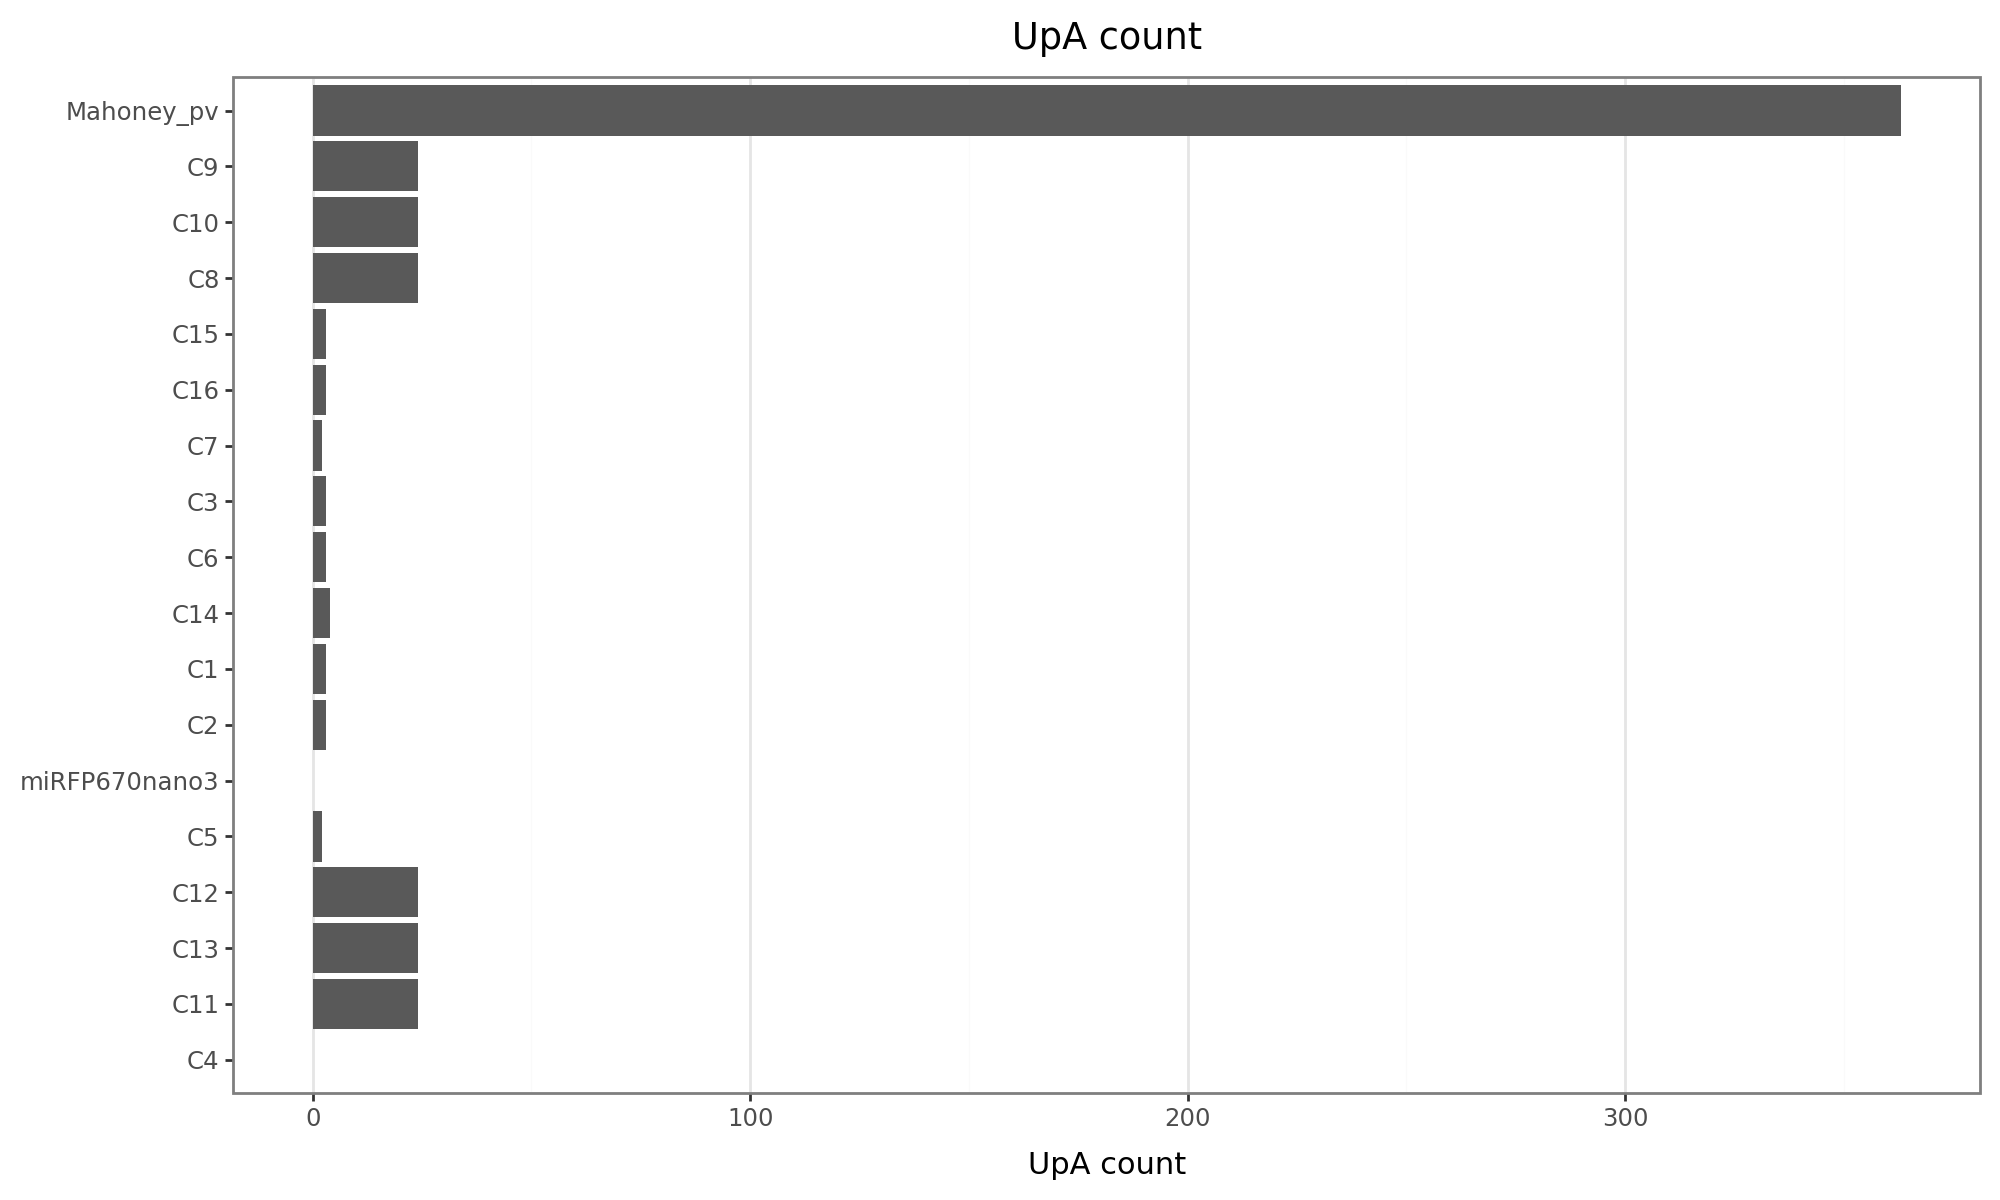

In [206]:
order = stats_df.sort_values("UpA count")["Construct"]
stats_df["Construct"] = pd.Categorical(stats_df["Construct"], categories=order, ordered=True)


(
    pln.ggplot(stats_df, pln.aes(x="Construct", y="UpA count")) +
    pln.geom_col() +
    pln.theme_bw() +
    pln.theme(
        panel_grid_major_y=pln.element_blank(),
        figure_size=(10,6),
    ) +
    pln.labs(title="UpA count", x="") +
    pln.coord_flip() 
)